## Preliminaries (plotting GT FES)

In [14]:
import mdtraj as md
import h5py
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker

from openmm import unit
from typing import Optional, List, Tuple
from einops import rearrange, reduce, repeat
import os
from glob import glob

In [15]:
def rmsd(P, Q):
    """
    Compute RMSD per frame using Theobald's method (no explicit alignment).
    
    P: (n_frames, n_atoms, 3)
    Q: (n_frames, n_atoms, 3)

    Returns:
        rmsd_per_frame: (n_frames,)
    """
    # Q = np.repeat(Q, P.shape[0], axis=0)  # Ensure Q has the same number of frames as P
    P = torch.tensor(P, dtype=torch.float32)
    Q = torch.tensor(Q, dtype=torch.float32)

    # Center both structures
    P_centered = P - P.mean(dim=1, keepdim=True)
    Q_centered = Q - Q.mean(dim=1, keepdim=True)

    # Compute covariance matrix
    C = torch.matmul(P_centered.transpose(1, 2), Q_centered)  # (n_frames, 3, 3)

    # SVD on covariance matrix
    V, S, W = torch.linalg.svd(C)
    det = torch.det(torch.matmul(V, W.transpose(-1, -2)))
    sign_correction = det.sign()
    S_corrected = S.clone()
    S_corrected[:, -1] *= sign_correction  # fix last singular value

    dot = 2 * torch.sum(S_corrected, dim=-1)

    # Compute squared norms
    P_norm_sq = torch.sum(P_centered ** 2, dim=(1, 2))
    Q_norm_sq = torch.sum(Q_centered ** 2, dim=(1, 2))

    # RMSD² = (||P||² + ||Q||² - 2 * sum(S)) / N
    # dot = 2 * torch.sum(S, dim=-1)
    rmsd_sq = (P_norm_sq + Q_norm_sq - dot) / P.shape[1]
    # rmsd_sq = torch.clamp(rmsd_sq, min=0.0)

    return torch.sqrt(rmsd_sq)

In [16]:
# Reference PDBs for CV calculations.
bba_pdb = md.load("/home/ethanz/data_boltz_likelihood/bba/bba_1fme.pdb") # NMR ensemble, 34 conformers.
bba_ca_pdb = bba_pdb.atom_slice(bba_pdb.topology.select("name CA")) # Trajectory w/ 34 frames, 28 CA atoms each.

bba_ca_p = np.load("/home/ethanz/data_boltz_likelihood/bba/bba_ca_coords.npy")[::10] # (365234, 28, 3), in Angstroms.
ref_ca_p = bba_ca_pdb.xyz * 10 # Converting MDTraj nm to Angstroms. (1, 28, 3)

helix_pdb = md.load("/home/ethanz/data_boltz_likelihood/bba/helix.pdb")
helix_ca_pdb = helix_pdb.atom_slice(helix_pdb.topology.select("name CA"))
helix_ca_p = helix_ca_pdb.xyz * 10 # Converting MDTraj nm to Angstroms.

boltz_pdb = md.load("/home/ethanz/data_boltz_likelihood/bba/bba_model_0.pdb")
print(f"{boltz_pdb.xyz.shape = }")
print([res.name for res in boltz_pdb.topology.residues])
print(boltz_pdb.n_residues)
print(boltz_pdb.atom_slice(boltz_pdb.top.select("protein")).xyz.shape)

boltz_pdb.xyz.shape = (1, 250, 3)
['GLU', 'GLN', 'TYR', 'THR', 'ALA', 'LYS', 'TYR', 'LYS', 'GLY', 'ARG', 'THR', 'PHE', 'ARG', 'ASN', 'GLU', 'LYS', 'GLU', 'LEU', 'ARG', 'ASP', 'PHE', 'ILE', 'GLU', 'LYS', 'PHE', 'LYS', 'GLY', 'ARG']
28
(1, 250, 3)


In [17]:
# # What PDB is this?
# fg_pdb = md.load("/home/ethanz/data_boltz_likelihood/bba/filtered.pdb")
# fg_pdb = fg_pdb.atom_slice(fg_pdb.topology.select("protein"))
# print(f"{fg_pdb.xyz.shape = }")
# print([res.name for res in fg_pdb.topology.residues])
# print(fg_pdb.n_residues)
# print(fg_pdb.atom_slice(fg_pdb.topology.select("protein")).xyz.shape)

In [18]:
# # Get the common atom indices between fg_pdb and boltz_pdb
# fg_atom_indices = []

# for res_idx, (fg_res, boltz_res) in enumerate(zip(fg_pdb.topology.residues, boltz_pdb.topology.residues)):
#     # Get atoms in both residues
#     fg_atoms = list(fg_res.atoms)
#     boltz_atoms = list(boltz_res.atoms)
    
#     # Find common atom names
#     boltz_atom_names = {atom.name for atom in boltz_atoms}
    
#     for fg_atom in fg_atoms:
#         if fg_atom.name in boltz_atom_names:
#             fg_atom_indices.append(fg_atom.index)

# # Create new trajectory with only the common atoms
# fg_filtered_traj = fg_pdb.atom_slice(fg_atom_indices)
# print(f"Original fg_pdb atoms: {fg_pdb.n_atoms}")
# print(f"Filtered fg_pdb atoms: {fg_filtered_traj.n_atoms}")
# print(f"boltz_pdb atoms: {boltz_pdb.n_atoms}")

# # check that the atom order is the same
# filtered_atoms = [atom.name for atom in fg_filtered_traj.top.atoms]
# boltz_atoms = [atom.name for atom in boltz_pdb.top.atoms]
# print(filtered_atoms)
# print(boltz_atoms)
# print(f"{(filtered_atoms == boltz_atoms) = }")

In [19]:
def transform_a(x):
        # x = (1 - x**8) / (1- x**12)
        x = np.log(x + 2)
        return x

def transform_b(x):
        # x = 1 - (1 / (1 + np.exp(3  - (0.75) *  x)))
        x = np.log(x + 1)
        return x

def get_bba_rc(ca_positions, topology=bba_ca_pdb.topology):
    """Computes reaction coordinates for BBA.

    ca_positions : (n_frames, n_carbons, 3) in angstroms.
    """
    # ca_positions should already be CA-only coordinates
    # Don't try to select CA again if it's already CA-only
    if ca_positions.shape[1] == len(topology.select("name CA")):
        # Already CA-only
        pass
    else:
        # Full structure, need to select CA
        ca_positions = ca_positions[:, topology.select("name CA"), :]

    ref0 = np.repeat(ref_ca_p, ca_positions.shape[0], axis=0)
    helix_ref = np.repeat(helix_ca_p, ca_positions.shape[0], axis=0)
    a = transform_a(rmsd(ca_positions[:, 15:26, :], helix_ref[:, 15:26, :]).numpy())
    b = transform_b(rmsd(ca_positions[:, 3:15, :], ref0[:, 3:15, :]).numpy())
    
    return np.concatenate([a[:, None], b[:, None]], axis=1)

### Wrangling the all-atom trajectory into Boltz topology.

In [20]:
# All-atom GT BBA trajectory. USE THIS ONE.
aa_coords = np.load("/home/ethanz/data_boltz_likelihood/bba/bba_all_atom_positions.npy")[::10]
aa_topology = md.load("/home/ethanz/data_boltz_likelihood/bba/bba_all_atom_topology.pdb").topology
gt_allatom_traj = md.Trajectory(xyz=aa_coords, topology=aa_topology)

# Processing code from src/lutils.pdb_processing.
# Trying to get the coordinates of the boltz topology atoms to construct a boltz topology compatible trajectory.
# -------------------------------------------------------------------- #
import re
def _get_resnum(atom_name: str) -> int:
    """Helper function to extract residue ID from a full atom name."""
    match = re.search(r'(\d+)', atom_name)
    return int(match.group(1))

coord_list = []
elements = []
masses = []

traj_coords = {
    str(list(gt_allatom_traj.topology.atoms)[i]): (
        gt_allatom_traj.xyz[:, i, :], # gets this in nanometers because it's mdtraj
        atom.element.symbol,
        atom.element.mass
    )
    for i, atom in enumerate(gt_allatom_traj.topology.atoms)

} # Keys: eg. 'ACE1-CA'. 
# Values: eg. (single-atom coord array of (n_frames, 3), 'C', 12.0)
# Note: residue indices might not start on 1.

# For PDB proteins, the chain might not start on residue 1.
first_atom = str(list(gt_allatom_traj.topology.atoms)[0]) # eg. LYS1-N
first_res_idx = _get_resnum(first_atom)

# start = first_res_idx + 1 if has_ace else first_res_idx
start = first_res_idx # bba_all_atom_topology.pdb has no ACE.
from boltz.data import const
ref_atoms = const.ref_atoms
BBA_SEQ = "EQYTAKYKGRTFRNEKELRDFIEKFKGR"
yaml_seq_3 = [
    const.prot_letter_to_token[res] for res in BBA_SEQ
]

for i, res in enumerate(yaml_seq_3, start=start):
    boltz_atom_ordering = ref_atoms[res]
    for atom in boltz_atom_ordering:
        atom_fullname = f'{res}{i}-{atom}'
        try:
            coord_list.append(traj_coords[atom_fullname][0])
            elements.append(traj_coords[atom_fullname][1])
            masses.append(traj_coords[atom_fullname][2])
        except Exception as e:
            raise Exception(
                f"A Boltz canonical atom {atom} is missing in PDB, "
                f"residue {res}{i}."
            ) from e

pdb_coords = np.stack(coord_list).transpose(1, 0, 2) # (n_frames, n_atoms, 3)
pdb_coords = pdb_coords - pdb_coords.mean(axis=0, keepdims=True) # Centering to origin. IN NM

filtered_traj = md.Trajectory(xyz=pdb_coords, topology=boltz_pdb.topology)
print("Traj shape:", filtered_traj.xyz.shape)
gt_ca_traj = filtered_traj.atom_slice(filtered_traj.topology.select("name CA"))
bba_ca_positions = gt_ca_traj.xyz * 10 # Converting MDTraj nm to Angstroms for CV calculation.

Traj shape: (364504, 250, 3)


(364504, 2)


Text(0, 0.5, 'TIC 1')

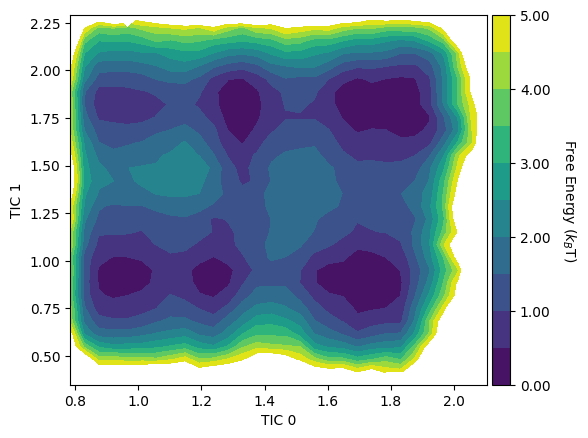

In [21]:
cv = get_bba_rc(bba_ca_positions)
print(cv.shape)

init_z, init_rc1_edge, init_rc2_edge = np.histogram2d(cv[:, 0], 
                                                      cv[:, 1],
                                                        bins=30)


init_rc1 = 0.5 * (init_rc1_edge[:-1] + init_rc1_edge[1:])
init_rc2 = 0.5 * (init_rc2_edge[:-1] + init_rc2_edge[1:])
init_z = init_z.T
init_z_density = init_z/float(init_z.sum())
init_free_energy = np.inf * np.ones(shape=init_z.shape)

nonzero = init_z_density.nonzero()
init_free_energy[nonzero] = -np.log(init_z_density[nonzero])
init_free_energy = init_free_energy - init_free_energy.min()

vmax = 5
plt.contourf(init_rc1, init_rc2, init_free_energy,
                levels=np.linspace(0, vmax, vmax * 2 + 1))
cbar = plt.colorbar(boundaries=np.linspace(0, vmax, vmax * 2 + 1), pad=0.01)
cbar.set_label(r"Free Energy ($k_B$T)", rotation=270, labelpad=20)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
# center = [1.7, 1.8]
# plt.scatter(center[0], center[1], color='red')

# bba_ca_pdb = bba_pdb.atom_slice(bba_pdb.topology.select("name CA"))
# bba_umbrella_start_pos = md.load("/home/ethanz/data_boltz_likelihood/bba/all_bba_start_positions.pdb")
# bba_umbrella_start_pos_ca = bba_umbrella_start_pos.atom_slice(bba_umbrella_start_pos.topology.select("name CA")).xyz * 10 # Converting MDTraj nm to Angstroms.
# start_pos_rcs = get_bba_rc(bba_umbrella_start_pos_ca)
# plt.scatter(start_pos_rcs[:, 0], start_pos_rcs[:, 1], color='blue', s=10, label="Umbrella Start Positions")

plt.xlabel("TIC 0")
plt.ylabel("TIC 1")
# # plt.savefig("figures/trpcage/trpcage_schnet_free_energy.pdf", dpi=300)

## Setup for Umbrella Simulation

### Defining Centers for umbrella simulations.

Text(0, 0.5, 'TIC 1')

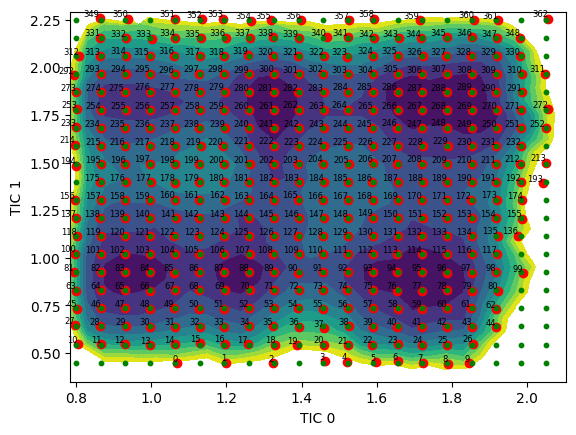

In [9]:
from scipy.spatial import cKDTree
plt.contourf(init_rc1, init_rc2, init_free_energy,
                levels=np.linspace(0, vmax, vmax * 2 + 1))

def make_grid(A, B, C, D, nx, ny):
    """
    Create a 2D grid of points as a numpy array of shape (n_points, 2).

    Args:
        A: min x
        B: max x
        C: min y
        D: max y
        nx: number of points along x axis
        ny: number of points along y axis

    Returns:
        points: np.ndarray of shape (nx * ny, 2)
    """
    x = np.linspace(A, B, nx)
    y = np.linspace(C, D, ny)
    xx, yy = np.meshgrid(x, y)
    points = np.column_stack([xx.ravel(), yy.ravel()])
    return points

points = make_grid(0.8, 2.05, 0.45, 2.25, nx=20, ny=20)

tree = cKDTree(cv)

# Query nearest neighbor in B for each point in A.
# Throw away points that are too far away.
CUTOFF = 0.01 # adjust as necessary.
dists, all_indices = tree.query(points)
indices = []
for i, dist in enumerate(dists):
    if dist < CUTOFF:
        indices.append(all_indices[i])

closest_points = cv[indices]

plt.scatter(closest_points[:, 0], closest_points[:, 1], color='red')
for i, (x, y) in enumerate(closest_points):
    plt.text(x, y, str(i), fontsize=6, ha='right', va='bottom')

plt.scatter(points[:, 0], points[:, 1], color='green', s=10)
plt.xlabel("TIC 0")
plt.ylabel("TIC 1")

In [ ]:
# Removing point 358, keeping all the rest. 
indices_final = indices.copy()[:-1]
closest_points_final = cv[indices_final]
centers_to_save = filtered_traj[indices_final]

centers_to_save.save("/home/ethanz/data_boltz_likelihood/bba/bba_umbrella_centers_dense.pdb")
np.save("/home/ethanz/data_boltz_likelihood/bba/bba_umbrella_centers_dense_cvs.npy", closest_points_final)
# Sanity check: make sure the topology is the same as Boltz's.
a = md.Trajectory(xyz=filtered_traj.xyz, topology=md.load("/home/ethanz/data_boltz_likelihood/bba/bba_model_0.pdb").topology)

### (Optionally) sparsifying start positions for quicker unbiased simulations.

In [ ]:
start_positions = np.load("/global/cfs/cdirs/m4235/boltz_files/bba/start_positions.npy")
print(f"{start_positions.shape = }")
centers = np.load("/global/cfs/cdirs/m4235/boltz_files/bba/centers.npy")
print(f"{centers.shape = }")

In [ ]:
centers_hardcoded = np.load('/home/ethanz/data_boltz_likelihood/umbrella/bba/centers.npy')
# all_start_pdbs = md.load('/home/ethanz/data_boltz_likelihood/umbrella/bba/all_bba_start_positions.pdb')
all_start_pdbs = md.load('/home/ethanz/data_boltz_likelihood/bba/langevin_bba_start_positions.pdb')
all_start_pdbs_ca = all_start_pdbs.atom_slice(all_start_pdbs.topology.select("name CA"))

centers_calculated = get_bba_rc(all_start_pdbs.xyz * 10, topology=all_start_pdbs.topology)

Text(0, 0.5, 'TIC 1')

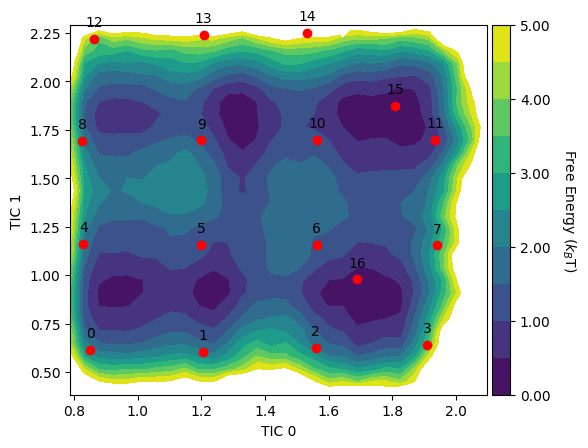

In [ ]:
init_z, init_rc1_edge, init_rc2_edge = np.histogram2d(cv[:, 0], 
                                                      cv[:, 1],
                                                        bins=30)


init_rc1 = 0.5 * (init_rc1_edge[:-1] + init_rc1_edge[1:])
init_rc2 = 0.5 * (init_rc2_edge[:-1] + init_rc2_edge[1:])
init_z = init_z.T
init_z_density = init_z/float(init_z.sum())
init_free_energy = np.inf * np.ones(shape=init_z.shape)

nonzero = init_z_density.nonzero()
init_free_energy[nonzero] = -np.log(init_z_density[nonzero])
init_free_energy = init_free_energy - init_free_energy.min()

vmax = 5
plt.contourf(init_rc1, init_rc2, init_free_energy,
                levels=np.linspace(0, vmax, vmax * 2 + 1))
cbar = plt.colorbar(boundaries=np.linspace(0, vmax, vmax * 2 + 1), pad=0.01)
cbar.set_label(r"Free Energy ($k_B$T)", rotation=270, labelpad=20)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

plt.scatter(centers_calculated[:, 0], centers_calculated[:, 1], color='red')
for i, (x, y) in enumerate(centers_calculated):
    plt.text(x, y + 0.05, str(i), ha='center', va='bottom')
# plt.scatter(centers_hardcoded[:, 0], centers_hardcoded[:, 1], color='blue')

selected_idx = 12
# plt.scatter(fg_cv[fg_start, 0], fg_cv[fg_start, 1], color='blue')

plt.xlabel("TIC 0")
plt.ylabel("TIC 1")
# # plt.savefig("figures/trpcage/trpcage_schnet_free_energy.pdf", dpi=300)

In [ ]:
center_idxs_kept_for_langevin = [0, 30, 61, 91, 3, 33, 64, 94, 6, 36, 67, 97, 9, 39, 70, 88, 73] # Even scatter + two stable confs (88, 73).
langevin_centers = all_start_pdbs[center_idxs_kept_for_langevin]
langevin_centers.save('/home/ethanz/data_boltz_likelihood/bba/langevin_bba_start_positions.pdb')

### Bias force setup for umbrella simulations

In [7]:
import torch.nn as nn
class BiasForceBBA(nn.Module):
    def __init__(self, centers: torch.Tensor, simulation_topology: md.Topology, bias_force:int =100.0):
        # simulation topology has the number of atoms you actually expect to simulate
        # for Boltz this means everything but the hydrogens
        # all positions should be in Angstroms
        super().__init__()
        self.centers = nn.Parameter(torch.tensor(centers, dtype=torch.float32))
        self.bias_force = bias_force
        self.batch_size = centers.shape[0]
        self.reference_ca = torch.tensor(ref_ca_p, dtype=torch.float32)
        self.reference_helix_ca = torch.tensor(helix_ca_p, dtype=torch.float32)

        ca_indices = simulation_topology.select("name CA")
        alpha_indices = ca_indices[15:26]
        beta_indices = ca_indices[3:15]


        self.alpha_indices = torch.tensor(alpha_indices, dtype=torch.long)
        self.beta_indices = torch.tensor(beta_indices, dtype=torch.long)

        self.ref_beta = self.reference_ca[:, 3:15, :]
        self.ref_beta = nn.Parameter(torch.cat([self.ref_beta for _ in range(self.batch_size)], dim=0))
        self.ref_helix = self.reference_helix_ca[:, 15:26, :]
        self.ref_helix = nn.Parameter(torch.cat([self.ref_helix for _ in range(self.batch_size)], dim=0))
        self.n_atoms = simulation_topology.n_atoms


    def rmsd(self, P: torch.Tensor, Q: torch.Tensor) -> torch.Tensor:
        """
        Compute RMSD per frame using Theobald's method (no explicit alignment).
        
        P: (n_frames, n_atoms, 3)
        Q: (n_frames, n_atoms, 3)

        Returns:
            rmsd_per_frame: (n_frames,)
        """
        # Center both structures
        P_centered = P - P.mean(dim=1, keepdim=True)
        Q_centered = Q - Q.mean(dim=1, keepdim=True)

        # Compute covariance matrix
        C = torch.matmul(P_centered.transpose(1, 2), Q_centered)  # (n_frames, 3, 3)

        # SVD on covariance matrix
        V, S, W = torch.linalg.svd(C)
        det = torch.det(torch.matmul(V, W.transpose(-1, -2)))
        sign_correction = det.sign()
        S_corrected = S.clone()
        S_corrected[:, -1] *= sign_correction  # fix last singular value

        dot = 2 * torch.sum(S_corrected, dim=-1)

        # Compute squared norms
        P_norm_sq = torch.sum(P_centered ** 2, dim=(1, 2))
        Q_norm_sq = torch.sum(Q_centered ** 2, dim=(1, 2))

        # RMSD² = (||P||² + ||Q||² - 2 * sum(S)) / N
        # dot = 2 * torch.sum(S, dim=-1)
        rmsd_sq = (P_norm_sq + Q_norm_sq - dot) / P.shape[1]
        # rmsd_sq = torch.clamp(rmsd_sq, min=0.0)

        return torch.sqrt(rmsd_sq)

    def transform_a(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.log(x + 2)
        return x

    def transform_b(self, x: torch.Tensor) -> torch.Tensor:
        x = torch.log(x + 1)
        return x

    def get_cv(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        a = self.transform_a(self.rmsd(x[:, self.alpha_indices, :], self.ref_helix))
        b = self.transform_b(self.rmsd(x[:, self.beta_indices, :], self.ref_beta)) 
        return a, b

    def energy(self, x: torch.Tensor) -> torch.Tensor:
        # x is shape (batch, n_atoms, 3)
        alpha_cv, beta_cv = self.get_cv(x)

        alpha_cv = (self.centers[:, 0] - alpha_cv) ** 2
        beta_cv = (self.centers[:, 1] - beta_cv) ** 2
        energy = self.bias_force * (alpha_cv + beta_cv)
        return energy
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x is shape (batch, n_atoms, 3)
        # Ensure input tensor requires gradients
        if not x.requires_grad:
            x = x.clone().detach().requires_grad_(True)
        
        energy: torch.Tensor = self.energy(x)
        grad_outputs: List[Optional[torch.Tensor]] = [torch.ones_like(energy)]
        grad = torch.autograd.grad([energy], [x], create_graph=False,
                                    grad_outputs=grad_outputs)
        # optional type refinement using an if statement
        if grad is None:
            grad = torch.zeros_like(x)
            print("Warning: Gradient is None, returning zeros.", flush=True)
        else:
            grad = grad[0]
        
        # optional type refinement using an assert
        assert grad is not None
        # return grad # Now grad is always a torch.Tensor instead of Optional[torch.Tensor]
        return -grad

In [13]:
# TODO: Change as appropriate.
centers = closest_points_final
simulation_topology = boltz_pdb.topology

bias_force = BiasForceBBA(centers=centers, simulation_topology=simulation_topology, bias_force=500.0)
scripted_bias_force = torch.jit.script(bias_force)
torch.jit.save(scripted_bias_force, "/home/ethanz/data_boltz_likelihood/bba/bias_force_bba_500_starts_dense.pt")
print(centers.shape, centers_to_save.n_frames) # Sanity check.

(362, 2) 362


## Visualizing simulations + saving trajectories

5 total checkpoints
5 valid checkpoints
Position shape: torch.Size([1000, 17, 250, 3])
Before subsampling: torch.Size([5000, 17, 250, 3])
5000 nonzero out of 5000
0 inf out of 5000
After removing invalid frames: torch.Size([5000, 17, 250, 3])


/tmp/ipykernel_513294/3635138961.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  P = torch.tensor(P, dtype=torch.float32)


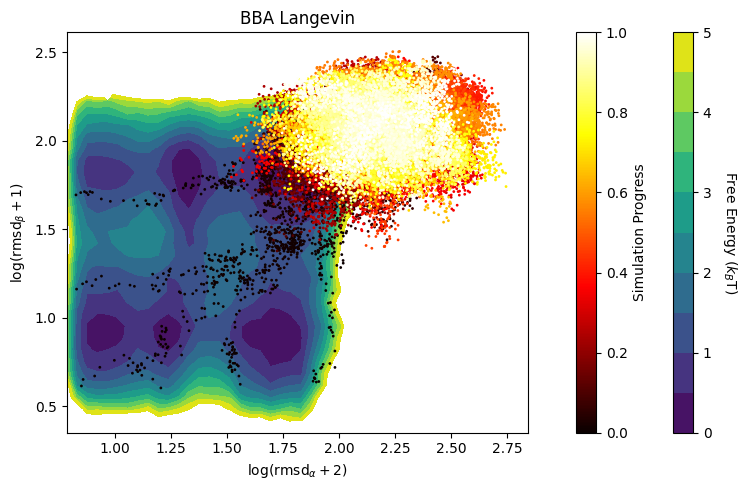

In [22]:
stride = 1
checkpoints = glob("/data2/scratch/ethanz/boltz_results_bba_OVRVO_masses_fixed_final_4080s/umbrella_0/cg_dataset_*.hdf5") # Simulation is saved in small segments (checkpoints).
print(len(checkpoints), "total checkpoints")
# only access hdf5 files which have a corresponding *_chk.pt file
checkpoints = [ckpt for ckpt in checkpoints if os.path.exists(ckpt.replace(".hdf5", "_chk.pt"))]
print(len(checkpoints), "valid checkpoints")

checkpoints = sorted(checkpoints, key=lambda x: int(x.split("_")[-1].split(".")[0]))
# checkpoints = checkpoints[:25] # Use for truncating trajectories if desired.

sampled_positions = []
for file in checkpoints:
    with h5py.File(file, "r") as file:
        pos_tensor = torch.tensor(file["positions"][::stride])
        sampled_positions.append(pos_tensor)

print('Position shape:', sampled_positions[0].shape) # Per checkpoint. (frames_per_checkpoint, num_windows, num_atoms, 3)
sampled_positions = torch.cat(sampled_positions, dim=0)

print("Before subsampling:", sampled_positions.shape) # (frames, windows, atoms, 3)
# count the number of nonzero frames
print(f"{(sampled_positions != 0.0).all((1,2,3)).sum()} nonzero out of {sampled_positions.shape[0]}")
print(f"{(sampled_positions.isinf()).all((1,2,3)).sum()} inf out of {sampled_positions.shape[0]}")

invalid = ((sampled_positions == 0.0).all((1,2,3)) | (sampled_positions.isinf()).all((1,2,3)))
sampled_positions = sampled_positions[~invalid]
print("After removing invalid frames:", sampled_positions.shape) # (frames, windows, atoms, 3)

sampled_positions = sampled_positions[:, :10, :, :]

# sampled_positions = sampled_positions[:100]
# print("After subsampling:", sampled_positions.shape) # (frames, windows, atoms, 3)
num_frames = sampled_positions.shape[0]


traj_progress = repeat(torch.arange(sampled_positions.shape[0]) / sampled_positions.shape[0], "frame -> frame window", window=sampled_positions.shape[1])
traj_progress = rearrange(traj_progress, "frame window -> (frame window)")
sampled_rcs = get_bba_rc(rearrange(sampled_positions, "frame window atom dim -> (frame window) atom dim"), 
                 boltz_pdb.topology)


# Plot BBA umbrella sampling trajectories.
init_z, init_rc1_edge, init_rc2_edge = np.histogram2d(cv[:, 0], 
                                                      cv[:, 1],
                                                        bins=30)


init_rc1 = 0.5 * (init_rc1_edge[:-1] + init_rc1_edge[1:])
init_rc2 = 0.5 * (init_rc2_edge[:-1] + init_rc2_edge[1:])
init_z = init_z.T
init_z_density = init_z/float(init_z.sum())
init_free_energy = np.inf * np.ones(shape=init_z.shape)

nonzero = init_z_density.nonzero()
init_free_energy[nonzero] = -np.log(init_z_density[nonzero])
init_free_energy = init_free_energy - init_free_energy.min()

vmax = 5

cmap = mpl.colormaps.get_cmap('hot')
plt.figure(figsize=(8, 5))
plt.contourf(init_rc1, init_rc2, init_free_energy,
             levels=np.linspace(0, vmax, vmax * 2 + 1))

cbar1 = plt.colorbar(pad=0.01)
cbar1.set_label(r"Free Energy ($k_B$T)", rotation=270, labelpad=20)

norm = mpl.colors.Normalize(vmin=0, vmax=1)
sc = plt.scatter(
    sampled_rcs[:, 0],
    sampled_rcs[:, 1],
    c=traj_progress,
    cmap=cmap,
    norm=norm,
    s=1
)

cbar2 = plt.colorbar(sc, pad=0.08)
cbar2.set_label("Simulation Progress")

plt.xlabel(r"$\log (\text{rmsd}_\alpha + 2)$")
plt.ylabel(r"$\log (\text{rmsd}_\beta + 1)$")
plt.title("BBA Langevin")
plt.tight_layout()
plt.show()

In [ ]:
# 7000 snapshots
# Saving 700 snapshots, every 10th.
# Each snapshot is 100 timesteps. Each timestep is 2 fs, so each final movie frame is 2 * 100 * 10 fs = 2ps.

In [23]:
# Saving all trajectories in a specified directory.
SAVE_DIR = "/home/ethanz/data_boltz_likelihood/bba/boltz_results_bba_OVRVO_masses_fixed_final_4080s/"
os.makedirs(SAVE_DIR, exist_ok=True)

num_windows = sampled_positions.shape[1]
for window_idx in range(num_windows):
    window_positions = sampled_positions[::10, window_idx, :, :].clone() / 10 # Convert to nm for mdtraj.
    window_traj = md.Trajectory(window_positions.numpy(), boltz_pdb.topology).center_coordinates()
    window_traj_superposed = window_traj.superpose(window_traj[0])
    window_traj_superposed.save(os.path.join(SAVE_DIR, f"bba_langevin_window_{window_idx}.pdb"))

### Umbrella Sampling Trajectory Visualization + Saving

In [ ]:
stride = 100
checkpoints = glob("/data2/scratch/ethanz/boltz_results_bba_umbrella_kabsch/umbrella_0/cg_dataset_*.hdf5")

print(len(checkpoints), "total checkpoints")
# only access hdf5 files which have a corresponding *_chk.pt file
checkpoints = [ckpt for ckpt in checkpoints if os.path.exists(ckpt.replace(".hdf5", "_chk.pt"))]
print(len(checkpoints), "valid checkpoints")
checkpoints = sorted(checkpoints, key=lambda x: int(x.split("_")[-1].split(".")[0]))
checkpoints = checkpoints[:10] # only look at the first 10 files for now

print(checkpoints)

sampled_positions = []
sampled_forces = []
sampled_velocities = []
for file in checkpoints:
    with h5py.File(file, "r") as file:
        pos_tensor = torch.tensor(file["positions"][::stride])
        # print(pos_tensor.shape)
        sampled_positions.append(pos_tensor)
        force_tensor = torch.tensor(file["forces"][::stride])
        sampled_forces.append(force_tensor)
        vel_tensor = torch.tensor(file["velocities"][::stride])
        sampled_velocities.append(vel_tensor)


sampled_positions = torch.cat(sampled_positions, dim=0)
print("Before subsampling:", sampled_positions.shape) # (frames, windows, atoms, 3)
# count the number of nonzero frames
print(f"{(sampled_positions != 0.0).all((1,2,3)).sum()} nonzero out of {sampled_positions.shape[0]}")
print(f"{(sampled_positions.isinf()).all((1,2,3)).sum()} inf out of {sampled_positions.shape[0]}")

invalid = ((sampled_positions == 0.0).all((1,2,3)) | (sampled_positions.isinf()).all((1,2,3)))
sampled_positions = sampled_positions[~invalid]
print("After removing invalid frames:", sampled_positions.shape) # (frames, windows, atoms,

# sampled_positions = sampled_positions[:100]
# print("After subsampling:", sampled_positions.shape) # (frames, windows, atoms, 3)
num_frames = sampled_positions.shape[0]

sampled_forces = torch.cat(sampled_forces, dim=0)
sampled_forces = sampled_forces[~invalid]
# sampled_forces = sampled_forces[::100]
# print("After subsampling:", sampled_forces.shape) # (frames, windows, atoms,

sampled_velocities = torch.cat(sampled_velocities, dim=0)
sampled_velocities = sampled_velocities[~invalid]


178 total checkpoints
177 valid checkpoints
['/data2/scratch/ethanz/boltz_results_bba_umbrella_kabsch/umbrella_0/cg_dataset_0.hdf5', '/data2/scratch/ethanz/boltz_results_bba_umbrella_kabsch/umbrella_0/cg_dataset_1.hdf5', '/data2/scratch/ethanz/boltz_results_bba_umbrella_kabsch/umbrella_0/cg_dataset_2.hdf5', '/data2/scratch/ethanz/boltz_results_bba_umbrella_kabsch/umbrella_0/cg_dataset_3.hdf5', '/data2/scratch/ethanz/boltz_results_bba_umbrella_kabsch/umbrella_0/cg_dataset_4.hdf5', '/data2/scratch/ethanz/boltz_results_bba_umbrella_kabsch/umbrella_0/cg_dataset_5.hdf5', '/data2/scratch/ethanz/boltz_results_bba_umbrella_kabsch/umbrella_0/cg_dataset_6.hdf5', '/data2/scratch/ethanz/boltz_results_bba_umbrella_kabsch/umbrella_0/cg_dataset_7.hdf5', '/data2/scratch/ethanz/boltz_results_bba_umbrella_kabsch/umbrella_0/cg_dataset_8.hdf5', '/data2/scratch/ethanz/boltz_results_bba_umbrella_kabsch/umbrella_0/cg_dataset_9.hdf5']
Before subsampling: torch.Size([100, 100, 250, 3])
100 nonzero out of 100
0

In [ ]:
traj_progress = repeat(torch.arange(sampled_positions.shape[0]) / sampled_positions.shape[0], "frame -> frame window", window=sampled_positions.shape[1])
traj_progress = rearrange(traj_progress, "frame window -> (frame window)")
sampled_rcs = get_bba_rc(rearrange(sampled_positions, "frame window atom dim -> (frame window) atom dim"), 
                 boltz_pdb.topology)

# TODO: re-include the drift stuff because I deleted it like a dum dum
# traj_progress_drift = repeat(torch.arange(sampled_positions_drift.shape[0]) / sampled_positions_drift.shape[0], "frame -> frame window", window=sampled_positions_drift.shape[1])
# traj_progress_drift = rearrange(traj_progress_drift, "frame window -> (frame window)")
# sampled_rcs_drift = get_bba_rc(rearrange(sampled_positions_drift, "frame window atom dim -> (frame window) atom dim"), 
#                  boltz_pdb.topology)

# sampled_rcs = rearrange(sampled_rcs, "(frame window) dim -> frame window dim", frame=num_frames)
print(sampled_rcs.shape)

(10000, 2)


/tmp/ipykernel_3346586/3880757755.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  P = torch.tensor(P, dtype=torch.float32)


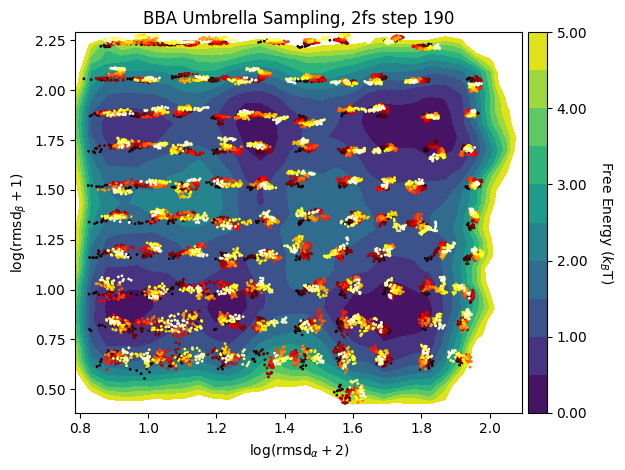

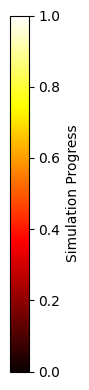

In [ ]:
# Plot BBA umbrella sampling trajectories.
init_z, init_rc1_edge, init_rc2_edge = np.histogram2d(cv[:, 0], 
                                                      cv[:, 1],
                                                        bins=30)


init_rc1 = 0.5 * (init_rc1_edge[:-1] + init_rc1_edge[1:])
init_rc2 = 0.5 * (init_rc2_edge[:-1] + init_rc2_edge[1:])
init_z = init_z.T
init_z_density = init_z/float(init_z.sum())
init_free_energy = np.inf * np.ones(shape=init_z.shape)

nonzero = init_z_density.nonzero()
init_free_energy[nonzero] = -np.log(init_z_density[nonzero])
init_free_energy = init_free_energy - init_free_energy.min()

vmax = 5
plt.contourf(init_rc1, init_rc2, init_free_energy,
                levels=np.linspace(0, vmax, vmax * 2 + 1))
cbar = plt.colorbar(boundaries=np.linspace(0, vmax, vmax * 2 + 1), pad=0.01)
cbar.set_label(r"Free Energy ($k_B$T)", rotation=270, labelpad=20)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
# plt.scatter(sampled_rcs[:, 0], sampled_rcs[:, 1], color='black', label='Boltz1 Samples', s=1)
cmap = mpl.colormaps.get_cmap('hot')
plt.scatter(sampled_rcs[:, 0], sampled_rcs[:, 1], color=cmap(traj_progress), label='Boltz1 Samples', s=1)

# TODO: scatter drift samples

plt.xlabel(r"$\log (\text{rmsd}_\alpha + 2)$")
plt.ylabel(r"$\log (\text{rmsd}_\beta + 1)$")
plt.title("BBA Umbrella Sampling, 2fs step 190")
# plt.legend(bbox_to_anchor=(1.35, 1), loc='upper left')
plt.tight_layout()
plt.show()

# make a dummy plot to get the colorbar
fig, ax = plt.subplots(figsize=(1, 4))
norm = mpl.colors.Normalize(vmin=0, vmax=1)
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=ax, label="Simulation Progress", pad=0.01)
plt.tight_layout()

### Saving Trajectories

In [ ]:
# take the above trajectories and make them into an mdtraj object
all_windows_sampled_traj = md.Trajectory(
    rearrange(sampled_positions / 10, "frame window atom dim -> (window frame) atom dim"), 
    boltz_pdb.topology).center_coordinates()

all_windows_sampled_traj_drift = md.Trajectory(
    rearrange(sampled_positions_drift / 10, "frame window atom dim -> (window frame) atom dim"),
    boltz_pdb.topology).center_coordinates()
# all_windows_sampled_traj.save("all_sampled_positions.pdb")

In [ ]:
# save the trajectory as a pdb file at the selected index
selected_idx = 12
selected_pos = sampled_positions[:,selected_idx,:,:].clone()/10 # put into nm for mdtraj
selected_pos_drift = sampled_positions_drift[:,selected_idx,:,:].clone()/10 # put into nm for mdtraj
print(selected_pos.shape)
print(selected_pos_drift.shape)

selected_traj = md.Trajectory(selected_pos.numpy(), boltz_pdb.topology).center_coordinates()
selected_traj_drift = md.Trajectory(selected_pos_drift.numpy(), boltz_pdb.topology).center_coordinates()

traj_atoms = [atom.element.symbol for atom in selected_traj.top.atoms]
traj_atoms_drift = [atom.element.symbol for atom in selected_traj.top.atoms]

print(traj_atoms == traj_atoms_drift)
# print(atoms == traj_atoms)
# selected_traj.save("drift_center.pdb")

torch.Size([250, 250, 3])
torch.Size([250, 250, 3])
True


/tmp/ipykernel_1359790/3880757755.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  P = torch.tensor(P, dtype=torch.float32)


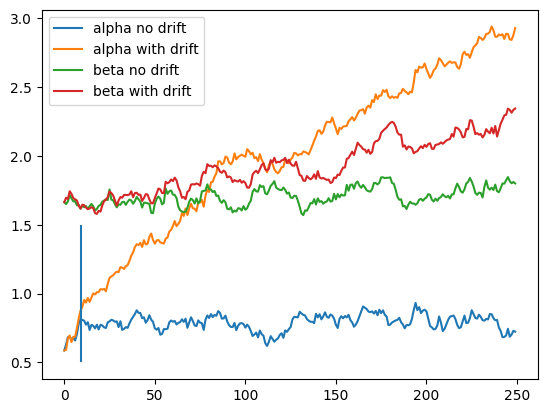

In [ ]:
# Debugging
rc = get_bba_rc(selected_pos * 10, boltz_pdb.topology)
rc_drift = get_bba_rc(selected_pos_drift * 10, boltz_pdb.topology)

rc.shape

plt.plot(rc[:,0], label='alpha no drift')
plt.plot(rc_drift[:,0], label='alpha with drift')
plt.plot(rc[:,1], label='beta no drift')
plt.plot(rc_drift[:,1], label='beta with drift')
plt.vlines(9, ymin=0.5, ymax=1.5)

plt.legend()
plt.show()

In [ ]:
# Grabbing trajectories for both drift and non-drift simulations.
selected_rc = get_bba_rc(selected_pos * 10, 
                 boltz_pdb.topology)

# Plotting both drift trajectory and non-drift trajectory
selected_progress = torch.arange(selected_rc.shape[0]) / selected_rc.shape[0]

/tmp/ipykernel_1359790/3880757755.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  P = torch.tensor(P, dtype=torch.float32)


In [ ]:
selected_rc_drift = selected_rc
selected_progress_drift = selected_progress

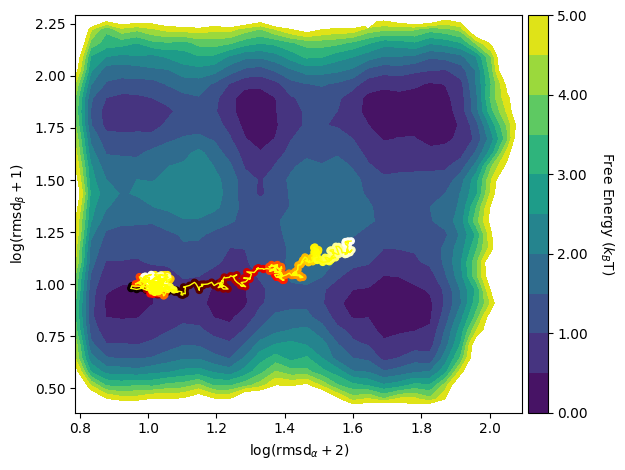

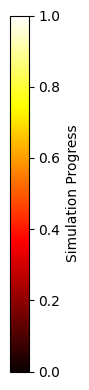

In [ ]:
plt.contourf(init_rc1, init_rc2, init_free_energy,
                levels=np.linspace(0, vmax, vmax * 2 + 1))
cbar = plt.colorbar(boundaries=np.linspace(0, vmax, vmax * 2 + 1), pad=0.01)
cbar.set_label(r"Free Energy ($k_B$T)", rotation=270, labelpad=20)
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
# plt.scatter(sampled_rcs[:, 0], sampled_rcs[:, 1], color='black', label='Boltz1 Samples', s=1)
cmap = mpl.colormaps.get_cmap('hot')

# Plotting both drifty and non-drifty trajectories.
plt.scatter(selected_rc_drift[:, 0], selected_rc_drift[:, 1], color=cmap(selected_progress), label='Boltz1 Samples', s=20)
plt.plot(selected_rc_drift[:, 0], selected_rc_drift[:, 1],  label='Boltz1 Samples', c='yellow', linewidth=1)
plt.scatter(selected_rc[:, 0], selected_rc[:, 1], color=cmap(selected_progress), label='Boltz1 Samples', s=20)
plt.plot(selected_rc[:, 0], selected_rc[:, 1],  label='Boltz1 Samples', c='yellow', linewidth=1)


plt.xlabel(r"$\log (\text{rmsd}_\alpha + 2)$")
plt.ylabel(r"$\log (\text{rmsd}_\beta + 1)$")
plt.tight_layout()
plt.show()

# make a dummy plot to get the colorbar
fig, ax = plt.subplots(figsize=(1, 4))
norm = mpl.colors.Normalize(vmin=0, vmax=1)
fig.colorbar(mpl.cm.ScalarMappable(norm=norm, cmap=cmap), cax=ax, label="Simulation Progress", pad=0.01)
plt.tight_layout()

Text(0, 0.5, 'RC Value')

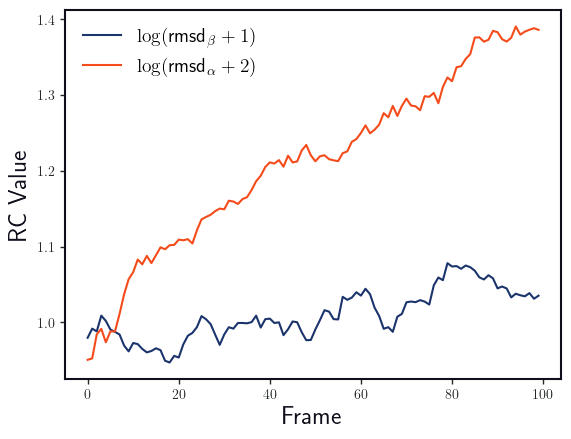

In [ ]:
plt.plot(selected_rc[:, 1], label=r"$\log (\text{rmsd}_\beta + 1)$")
plt.plot(selected_rc[:, 0], label=r"$\log (\text{rmsd}_\alpha + 2)$")
plt.legend()
plt.xlabel("Frame")
plt.ylabel("RC Value")

In [ ]:
loaded_bias_force = torch.jit.load("/global/cfs/cdirs/m4235/boltz_files/bba/bias_force_bba_500.pt")
loaded_bias_force.energy

In [ ]:
import tempfile
from tqdm import tqdm
from omm.omm import ProteinImplicit
import shutil
import tempfile

def compute_force_from_traj(
    traj: md.Trajectory, 
    amber_filename:str, 
    num_relax_steps:int=0, 
    temperature:float=300
):
    """Compute the heavy atom forces at every trajectory frame.

    Parameters
    ----------
    traj : md.Trajectory
        Trajectory to compute forces for.
    amber_filename : str
        Name of the .prmtop and .(inp)crd files of the system.
    
    Notes
    -----
    Assumes kT units with T = 300 Kelvin unless otherwise specified.
    """    
    simulation_args = {
        "temperature": temperature, 
        "temperature_units": "kelvin", 
        "friction": 100.0, "dt": 0.00002, 
        "time_units": "picoseconds", 
        "prior_weight": None, 
        "integrator_to_use": "overdamped", 
        "do_energy_minimization": False, 
        "chk_freq": 10000000, 
        "device": "OpenCL", 
        "fix":"backbone"
    }
    solvent_args = {
        "implicit_solvent": "OBC2", 
        "implicit_solvent_kappa": 0.1, 
        "implicit_solvent_kappa_length_units": "nanometer"
    }

    p = ProteinImplicit(
        filename = amber_filename, chk=0,
        simulation_args=simulation_args,
        solvent_args=solvent_args,
        save_filename = f"./"
        )

    gen_positions = traj.xyz # mdtraj saves in nanometers by default
    final_forces = []

    for i, position in tqdm(enumerate(gen_positions), mininterval=10):
        # Need to somehow add hydrogens to each position tensor. 
        pos, pe, ke, forces = p.relax_energies(
            10 * position, # convert to angstroms
            velocities=True,
            num_relax_steps=num_relax_steps, # 0 relax steps means no relaxation, just get energies
            length_units="angstroms",
            time_units="picoseconds",
            energy_units="kilocalories_per_mole",
            # energy_units="kT"
        )
        final_forces.append(forces)

    return np.stack(final_forces, axis=0)

# make sure to run tleap -f fix_pdb.in and tleap -f fix_traj.in
tleap_input = f"""
    source leaprc.ff99SBxildn
    protein = loadPDB /global/cfs/cdirs/m4235/boltz_files/bba/boltz_inference/boltz_results_bba_inference/predictions/bba/bba_model_0.pdb
    check protein
    savePdb protein amber_bba_single.pdb
    saveAmberParm protein amber_bba_single.prmtop amber_bba_single.crd
    quit
    """

result = subprocess.run(
    ["tleap", "-f", "-"],  # "-" means read from stdin
    input=tleap_input.encode(),
    stdout=subprocess.DEVNULL,  # suppress normal output
    check=True
)

# selected traj
traj_for_forces_path = "/global/homes/d/dunne/boltz-likelihoods/notebooks/selected_traj.pdb"

# diffusion iid inference traj
# traj_for_forces_path = "/global/cfs/cdirs/m4235/boltz_files/bba/boltz_inference/boltz_results_bba_inference/predictions/all_diffusion_structures.pdb"

tleap_input = f"""
    source leaprc.ff99SBxildn
    protein = loadPDB {traj_for_forces_path}
    saveAmberParm protein amber_bba_traj.prmtop amber_bba_traj.crd
    quit
    """

result = subprocess.run(
    ["tleap", "-f", "-"],  # "-" means read from stdin
    input=tleap_input.encode(),
    stdout=subprocess.DEVNULL,  # suppress normal output
    check=True
)

# turn the prmtop and crd files into a pdb file with hydrogens
subprocess.run("ambpdb -p amber_bba_traj.prmtop -c amber_bba_traj.crd > amber_bba_traj.pdb", shell=True, check=True)


CompletedProcess(args='ambpdb -p amber_bba_traj.prmtop -c amber_bba_traj.crd > amber_bba_traj.pdb', returncode=0)

In [ ]:
# fix the hydrogens in the pdb file using amber first. It gives us everything as a concatenated pdb file, so fix that
# amber_traj = md.load("/global/homes/d/dunne/boltz-likelihoods/notebooks/amber_bba_traj.pdb")
amber_traj = md.load("/global/homes/d/dunne/boltz-likelihoods/notebooks/amber_bba_traj.pdb")
amber_top = md.load("/global/homes/d/dunne/boltz-likelihoods/notebooks/amber_bba_single.pdb").topology
print(f"{amber_traj.xyz.shape = }")
amber_pos = rearrange(amber_traj.xyz, "1 (frame atom) dim -> frame atom dim", 
                      frame=selected_traj.xyz.shape[0],)
# amber_pos = rearrange(amber_traj.xyz, "1 (frame atom) dim -> frame atom dim", 
#                       frame=diffusion_structures.xyz.shape[0],)
fixed_amber_traj = md.Trajectory(amber_pos, amber_top).center_coordinates()
fixed_amber_traj.save("/global/homes/d/dunne/boltz-likelihoods/notebooks/fixed_amber_bba_traj.pdb")
print(f"{fixed_amber_traj.xyz.shape = }")

amber_traj.xyz.shape = (1, 50400, 3)
fixed_amber_traj.xyz.shape = (100, 504, 3)


In [ ]:
gt_forces = compute_force_from_traj(traj=fixed_amber_traj, amber_filename="/global/homes/d/dunne/boltz-likelihoods/notebooks/amber_bba_single", num_relax_steps=0, temperature=300)
heavy_atom_indices = amber_top.select("not element H and not name OXT")
gt_forces = torch.tensor(gt_forces[:, heavy_atom_indices, :])
print(torch.mean(torch.norm(gt_forces, dim=-1)))


100it [00:00, 472.19it/s]


tensor(2016385.9999, dtype=torch.float64)


In [ ]:
sampled_forces.shape

torch.Size([100, 100, 250, 3])

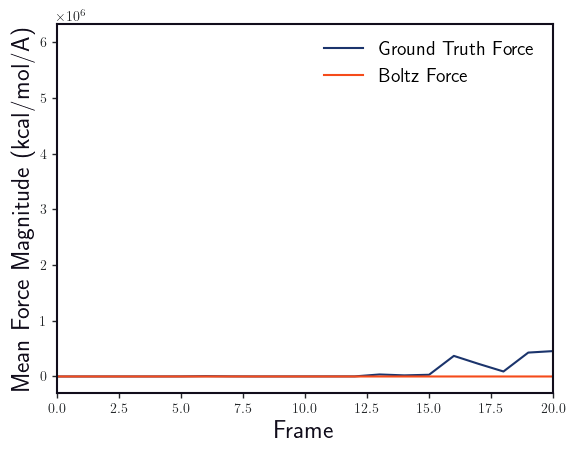

In [ ]:
fig, ax = plt.subplots()
ax.plot(np.arange(gt_forces.shape[0]), torch.norm(gt_forces, dim=-1).mean(axis=1), label="Ground Truth Force")
ax.plot(np.arange(sampled_forces.shape[0]), torch.norm(sampled_forces[:,selected_idx,:,:], dim=-1).mean(axis=1), label="Boltz Force")
ax.set_xlabel("Frame")
ax.set_xlim(0,20)
ax.set_ylabel("Mean Force Magnitude (kcal/mol/A)")
# ax.set_yscale("log")
ax.legend()
plt.show()